# Plot results from searching in data using the inpainting search

In [1]:
# This stuff only actually gets used in this cell:

from matplotlib import pyplot as plt

# Use the style file defined in the repository route
plt.style.use('../../paper.mplstyle')

# This is the folder where results plots for the paper will be saved:
paper_plots_dir = '../../paper/images/inpainting_results'

# The common and plotting utils modules are in the parent
# `search` directory
# Here we add the `search` directory to the python path so we can
# do a local import

import sys
import os

parent_dir = os.path.abspath("..")

if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)


# Everything plotted in this notebook is done using these helper modules
import plotting_utils
from common_utils import get_results_inpainting as get_results

/Users/gareth/miniconda3/envs/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [2]:
times_before = [0.5, 1, 4, 7, 14]

results_estimate_filtered = get_results(
    f"results/data_runs_psd_estimate.hdf",
    filter_times_before=times_before
)
results_model_filtered = get_results(
    f"results/data_runs_psd_model.hdf",
    filter_times_before=times_before
)

results_estimate_all = get_results(
    f"results/data_runs_psd_estimate.hdf"
)
results_model_all = get_results(
    f"results/data_runs_psd_model.hdf"
)


In [3]:
# Get the truth times
import ldc.io.hdf5 as hdfio

input_data = '../../datasets/LDC2_sangria_hm_training.hdf'
mbhb_sky = hdfio.load_array(input_data, name="sky/mbhb/cat")

truth_times_s = mbhb_sky[0]['CoalescenceTime']

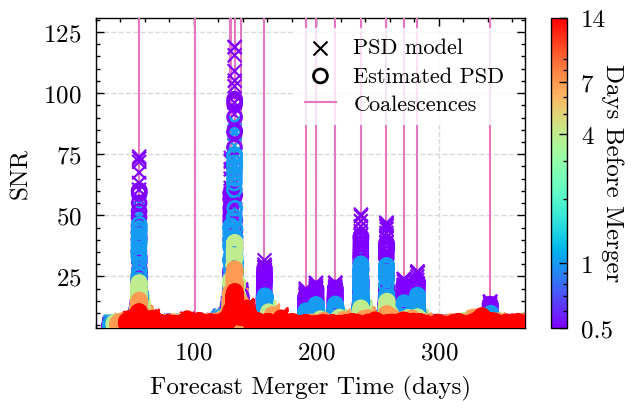

In [4]:
fig_filtered, _ = plotting_utils.plot_around_time(
    results_one=results_model_filtered,
    results_two=results_estimate_filtered,
    truth_times=truth_times_s,
    times_before=times_before,
    label_one='PSD model',
    label_two='Estimated PSD',
    legend_loc='upper right'
)


In [5]:
# BIG picture - comment out if you want this notebook to run within a sensible time
# fig_all, _ = plotting_utils.plot_around_time(
#     results_one=results_model_all,
#     results_two=results_estimate_all,
#     truth_times=truth_times_s,
#     times_before=times_before,
#     label_one='PSD model',
#     label_two='Estimated PSD',
#     legend_loc='upper right'
# )
# fig_all.savefig(f'plots/signals_results_all_forecast.png')

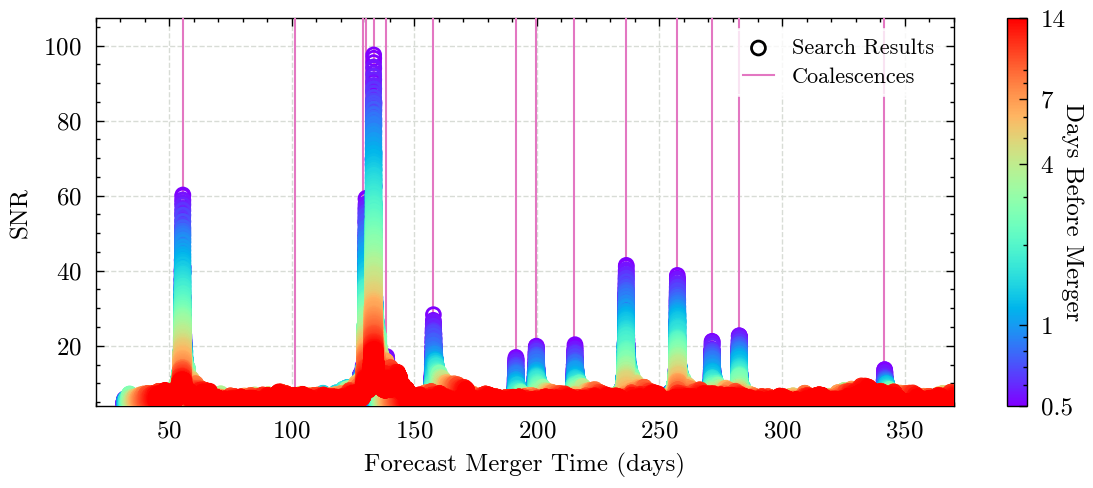

In [6]:
# BIG picture - comment out if you want this notebook to run fast
# this is the result used in the paper, so is on by default
fig_estimate, _ = plotting_utils.plot_around_time(
    results_one=results_estimate_all,
    truth_times=truth_times_s,
    times_before=times_before,
    label_one='Search Results',
    marker_one='o',
    legend_loc='upper right',
    width_factor=2,
    height_factor=1.25
)
fig_estimate.savefig(f'{paper_plots_dir}/figure_7_forecast_inpainting_estimate.png')

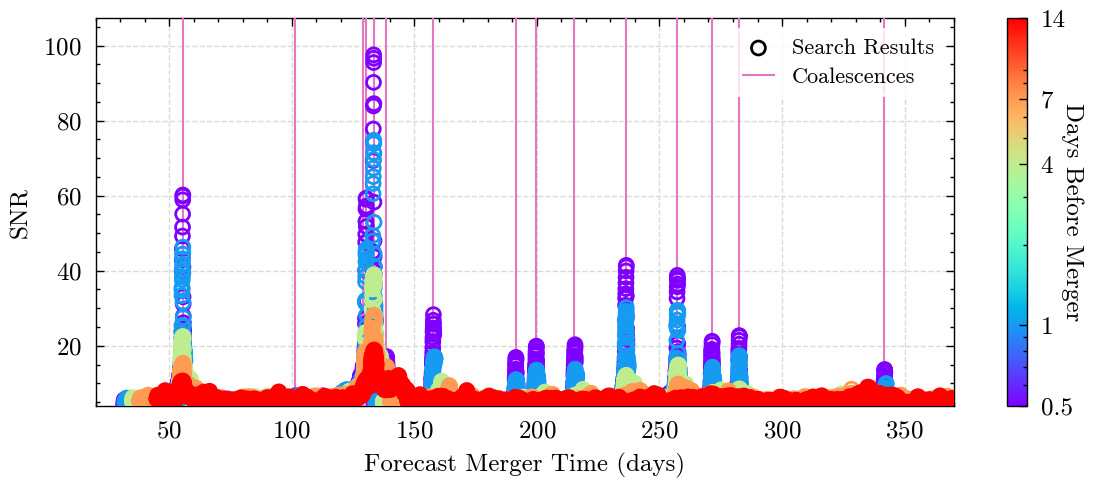

In [7]:

fig_estimate_filtered, _ = plotting_utils.plot_around_time(
    results_one=results_estimate_filtered,
    truth_times=truth_times_s,
    times_before=times_before,
    label_one='Search Results',
    marker_one='o',
    legend_loc='upper right',
    width_factor=2,
    height_factor=1.25
)

In [8]:
# fig_all, _ = plotting_utils.plot_around_time(
#     results_one=results_model_all,
#     results_two=results_estimate_all,
#     truth_times=truth_times_s,
#     times_before=times_before,
#     label_one='PSD model',
#     label_two='Estimated PSD',
#     predicted_time=False,
#     legend_loc='upper right'
# )

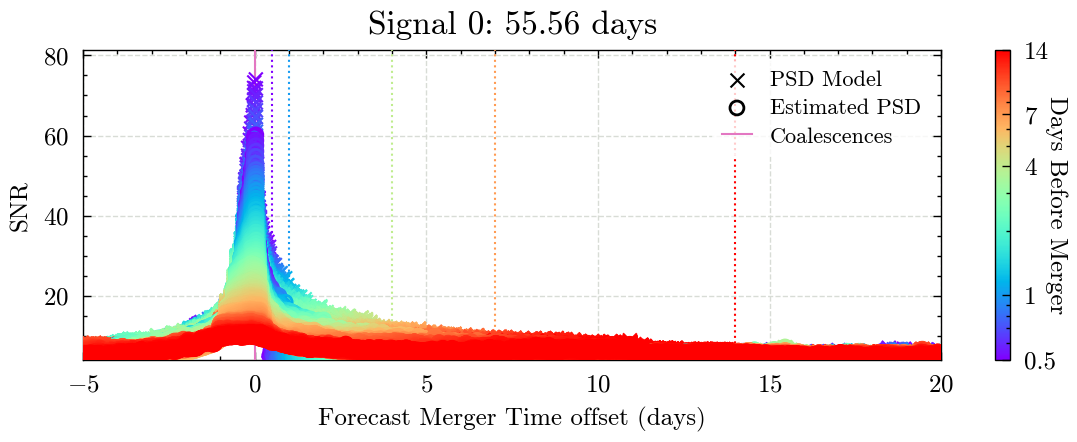

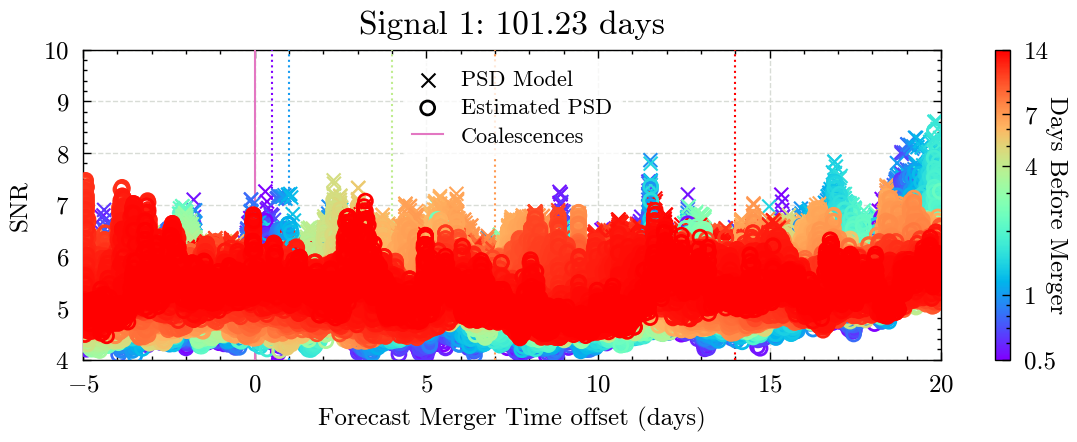

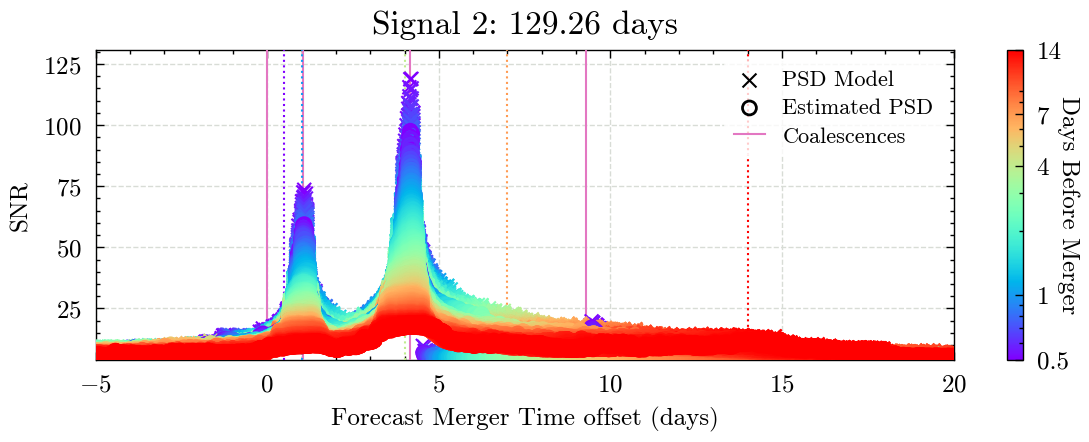

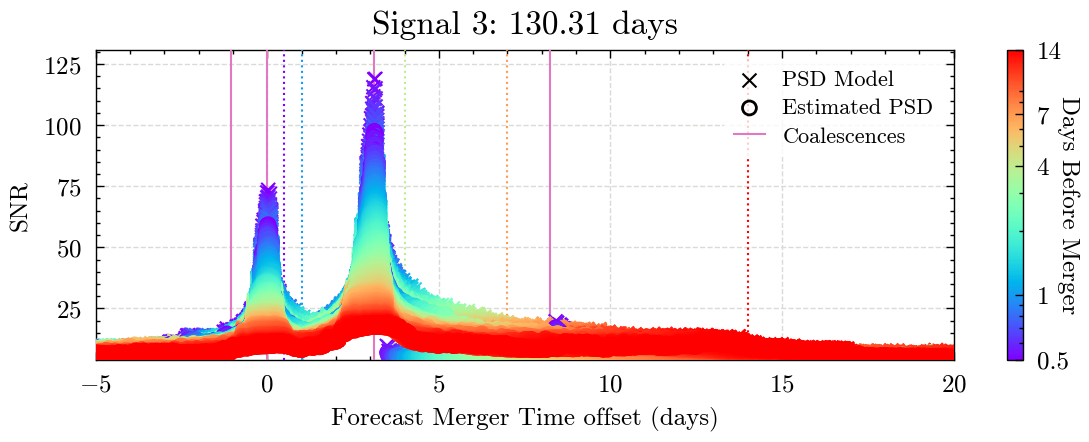

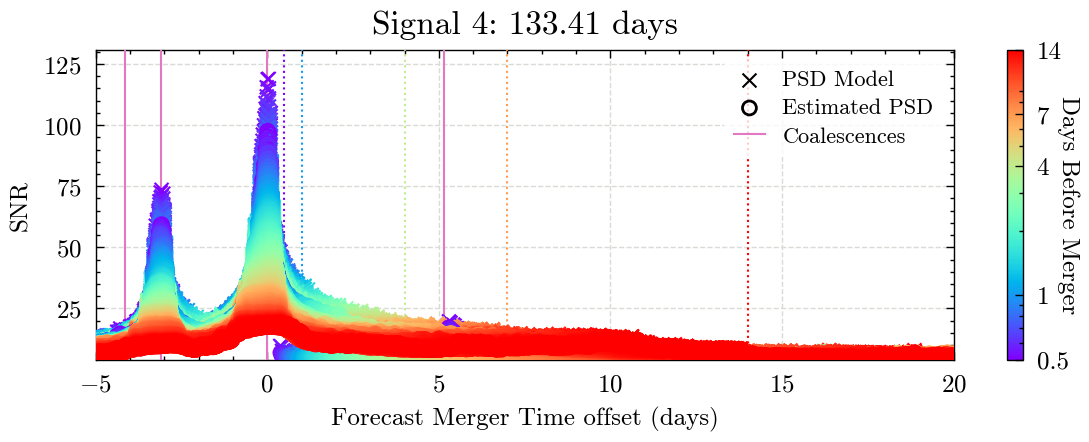

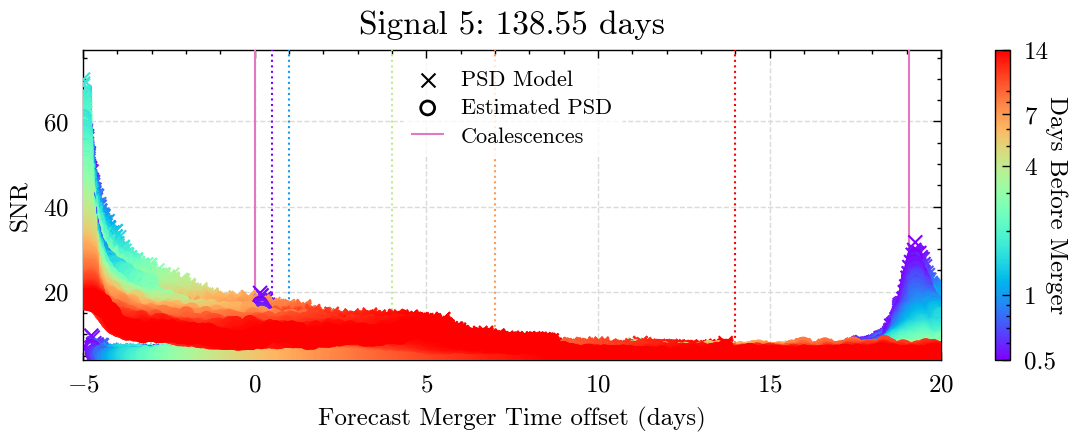

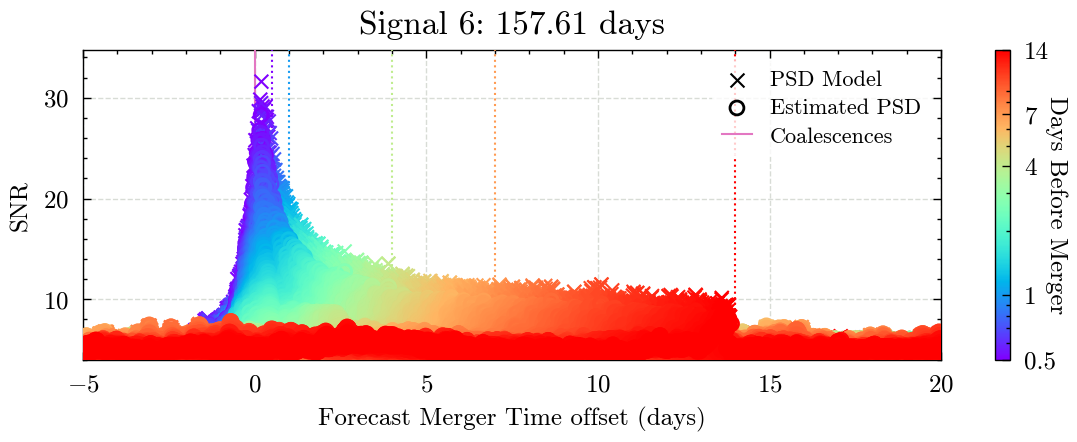

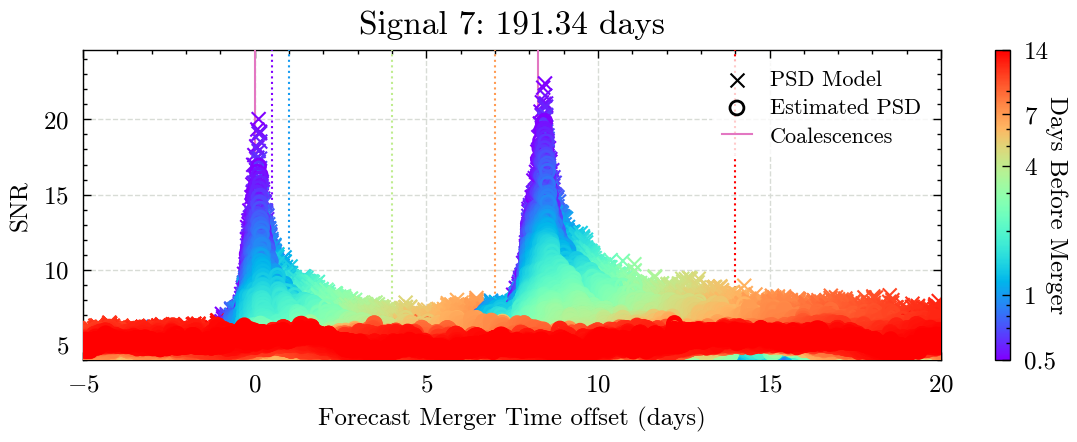

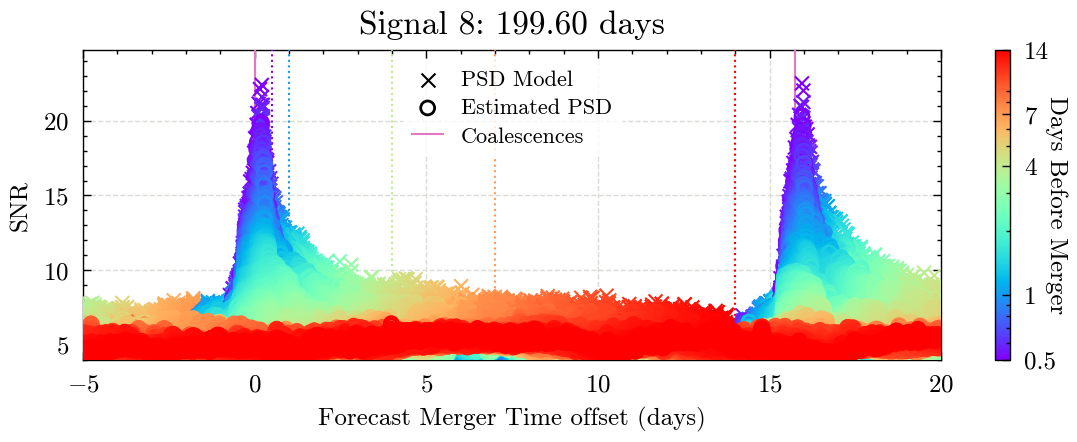

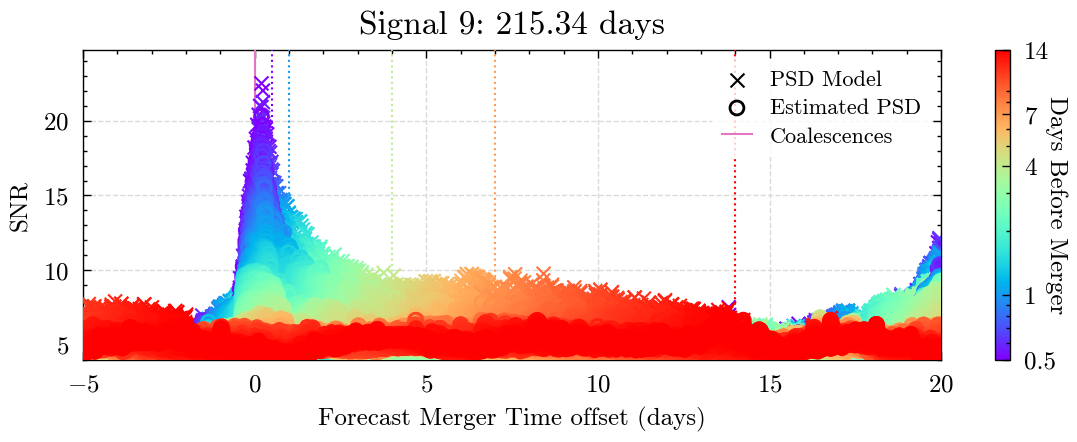

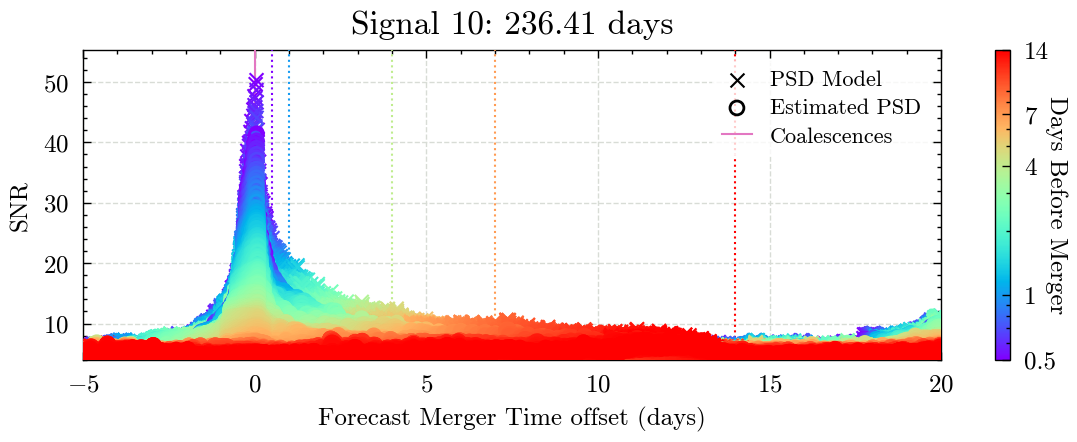

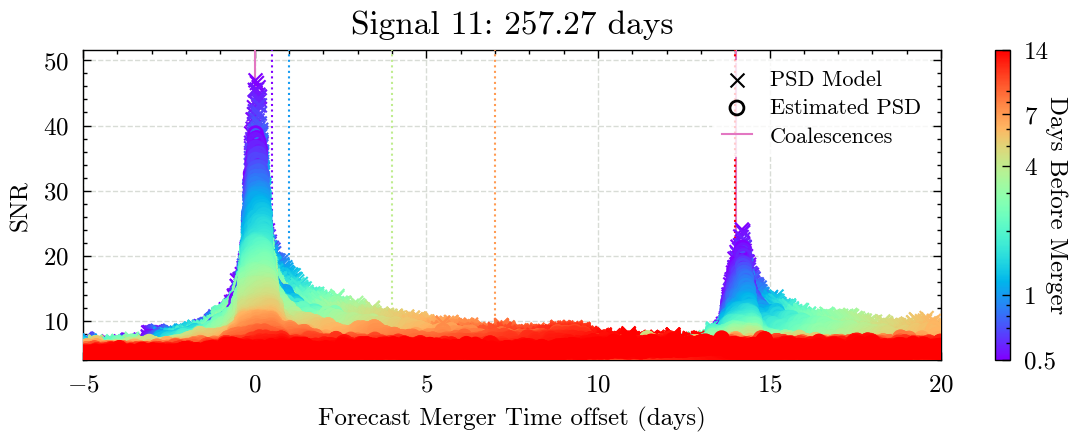

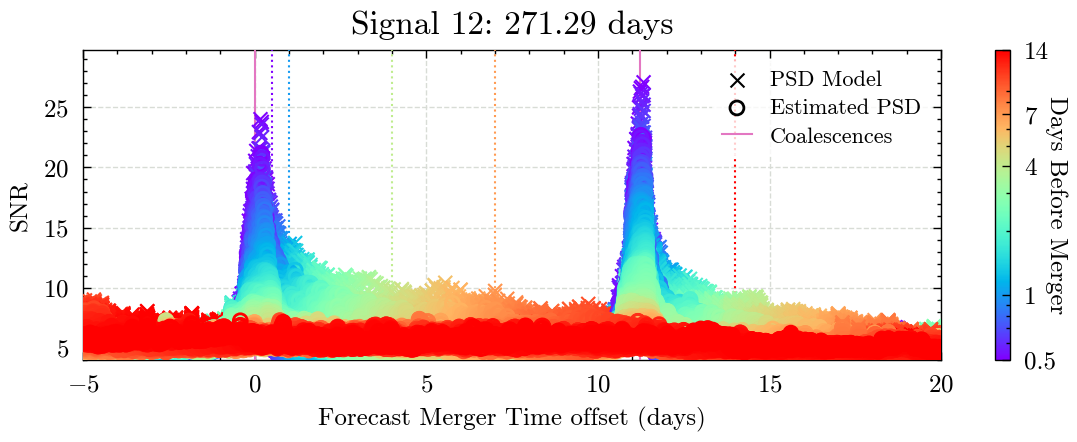

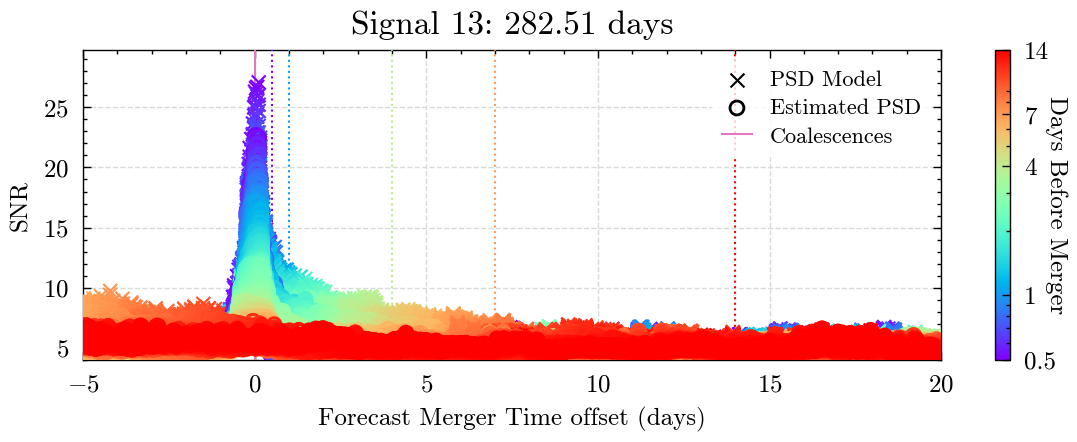

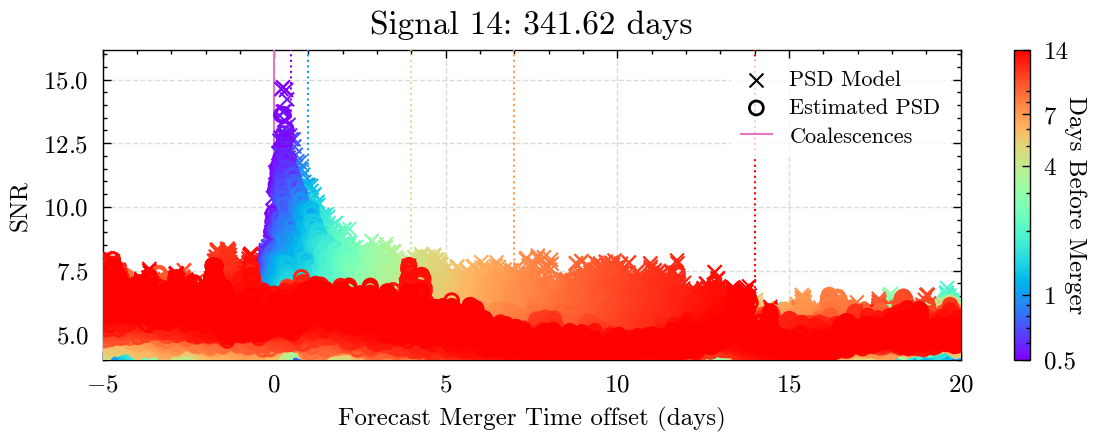

In [9]:
for i, truth_time_s in enumerate(truth_times_s):
    fig_model, _ = plotting_utils.plot_around_time(
        results_one=results_model_all,
        results_two=results_estimate_all,
        signal_truth_time=truth_time_s,
        truth_times=truth_times_s,
        start_time_offset=-5,
        end_time_offset=20,
        times_before=times_before,
        signal_number=i,
        label_one='PSD Model',
        label_two='Estimated PSD',
        legend_loc='upper center' if i in [1,5,8] else 'upper right',
        width_factor=2
    )

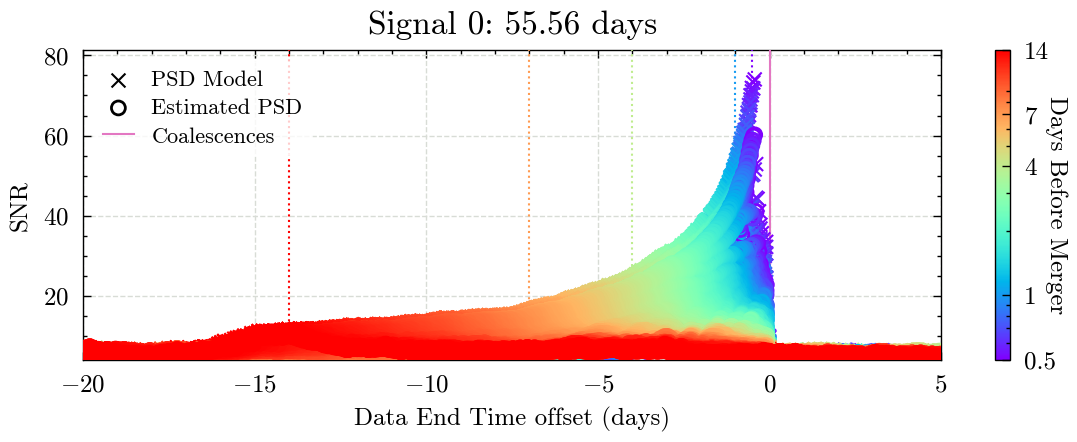

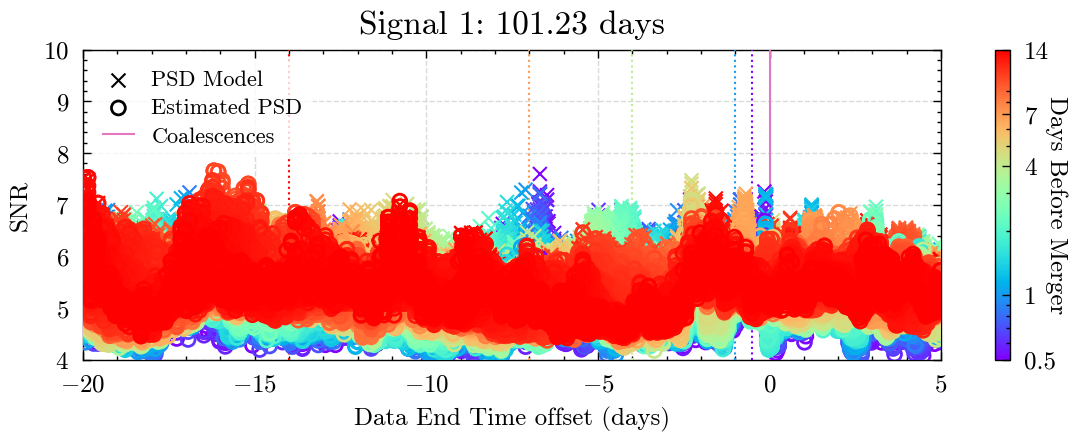

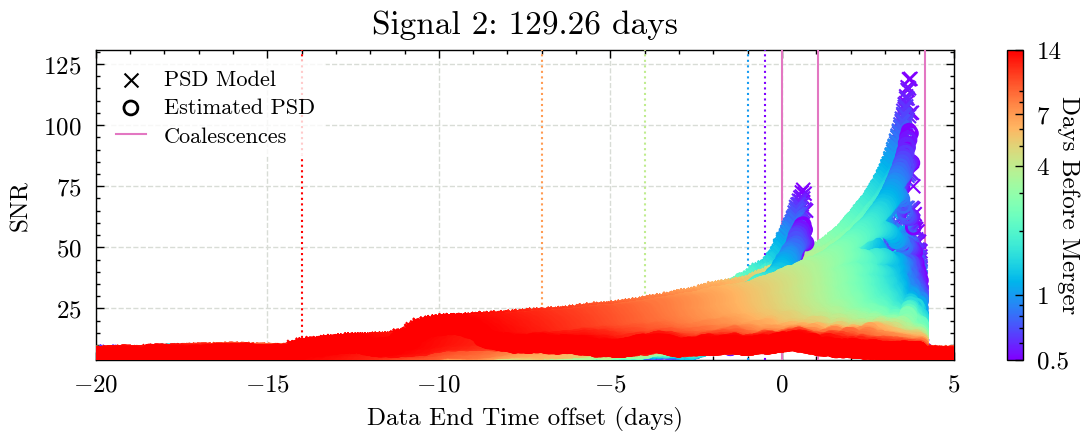

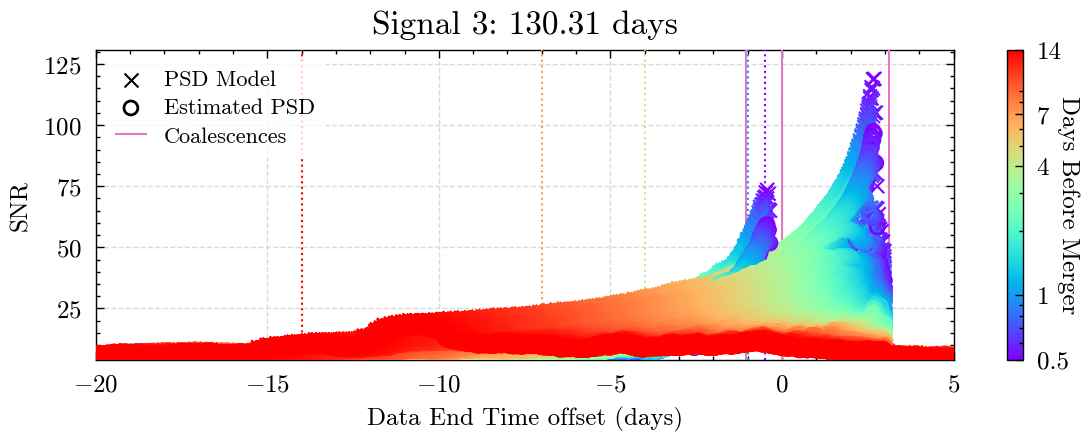

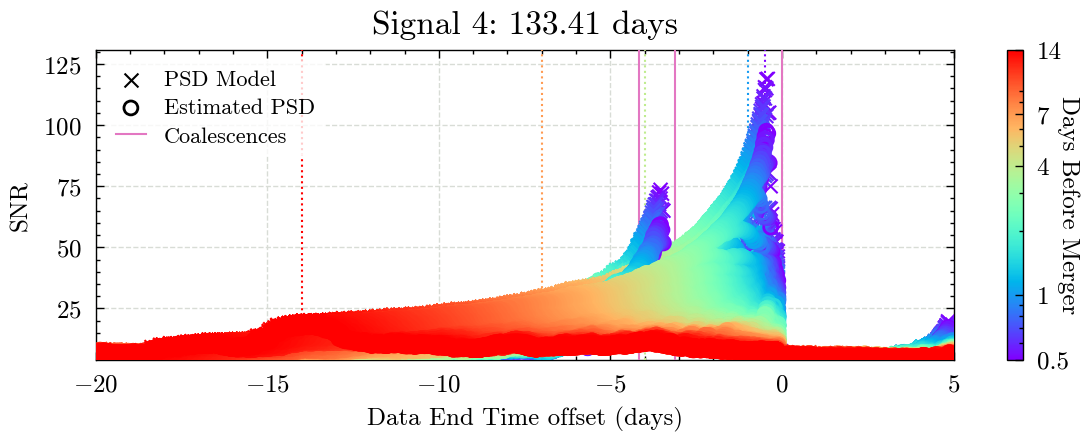

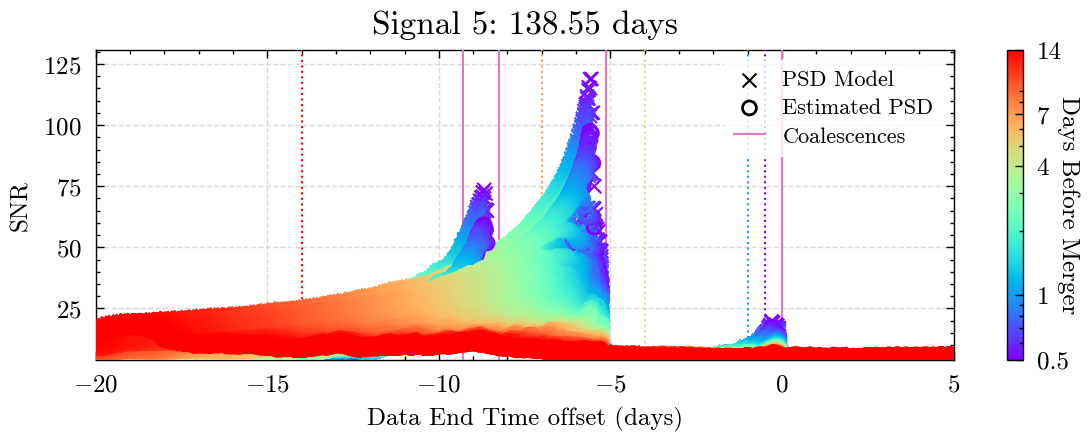

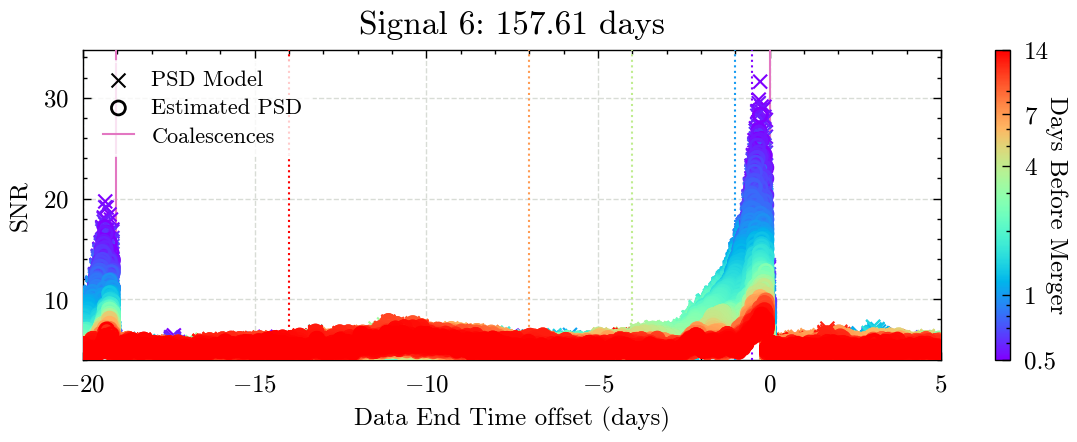

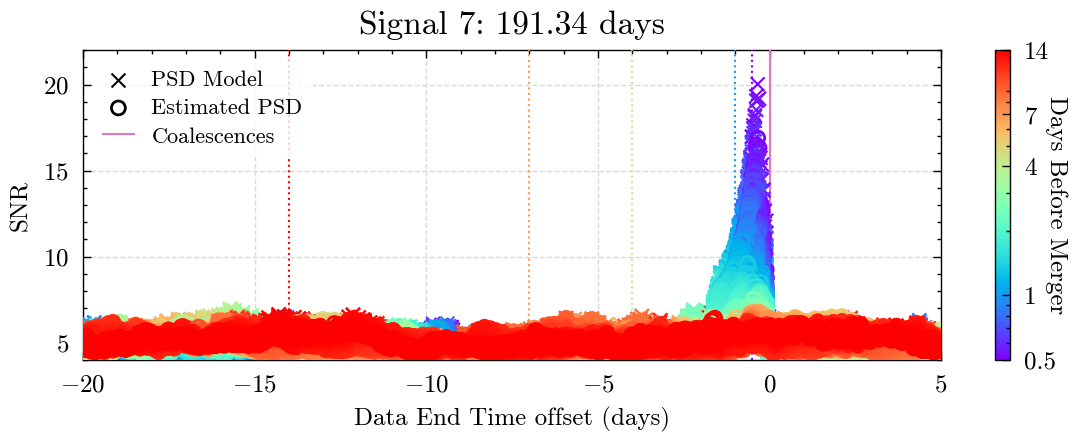

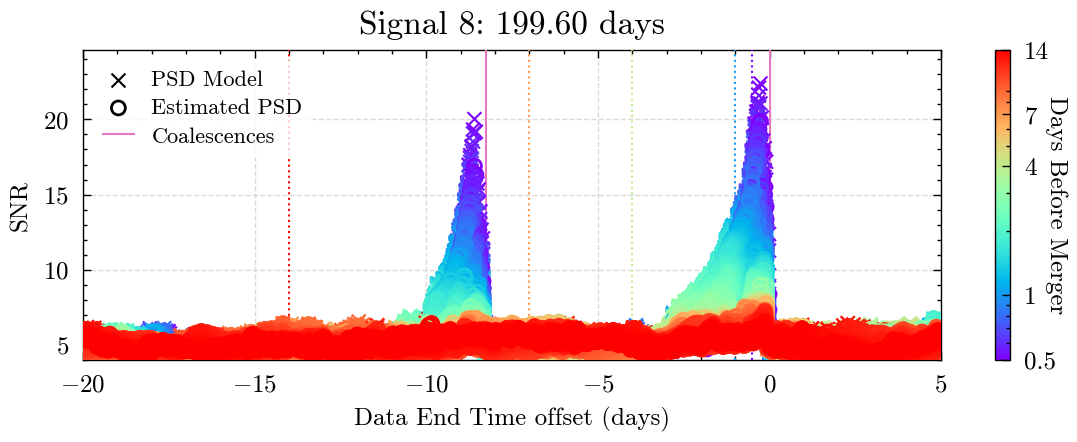

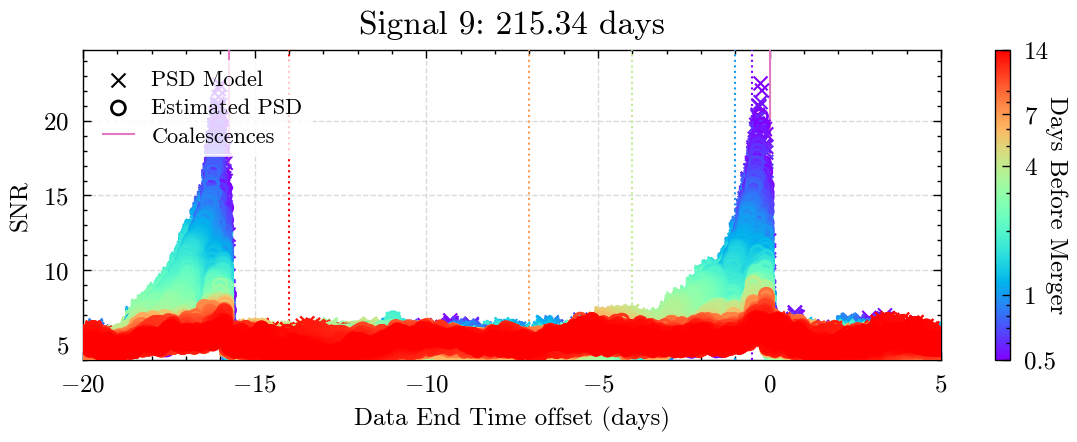

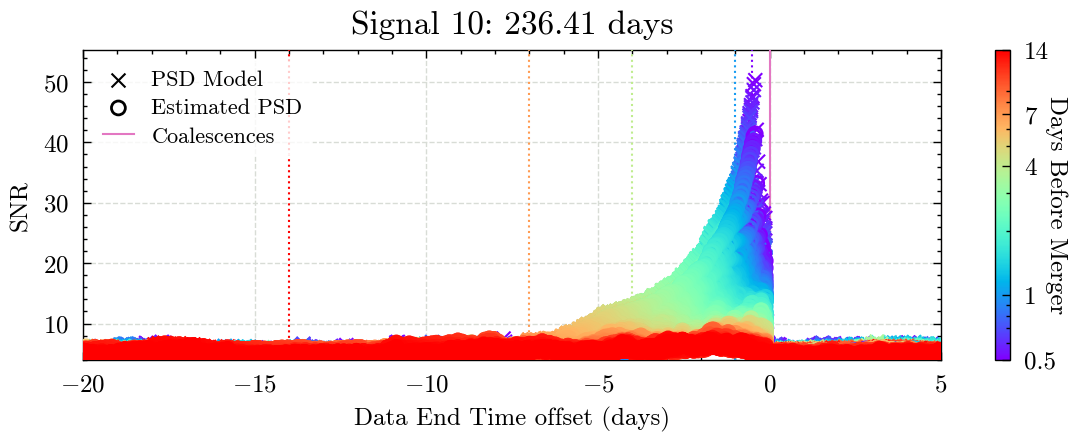

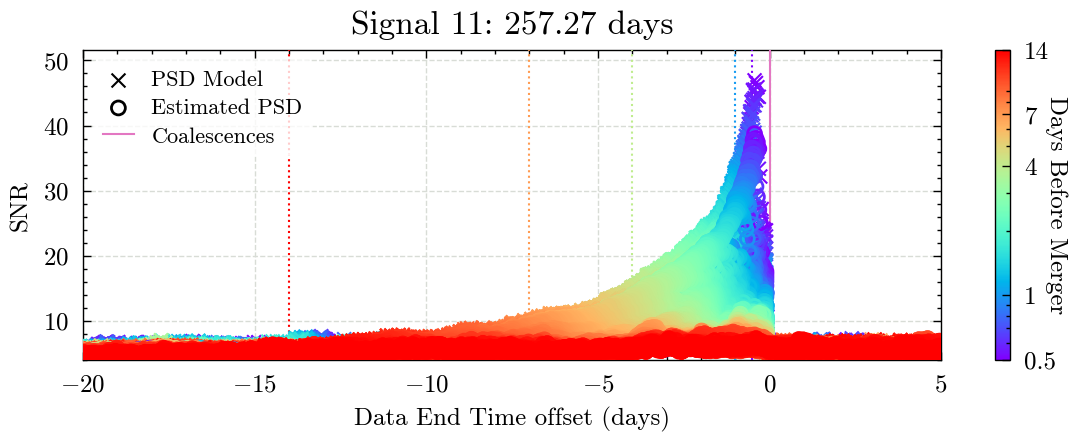

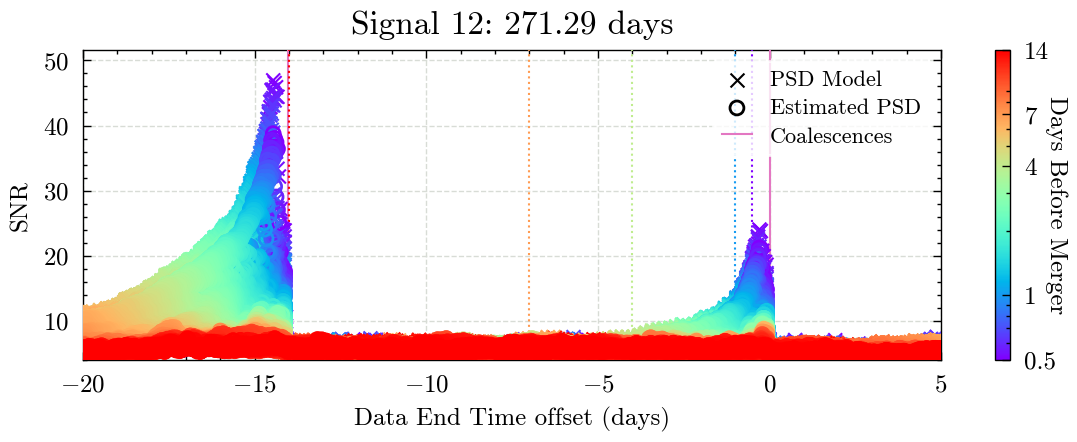

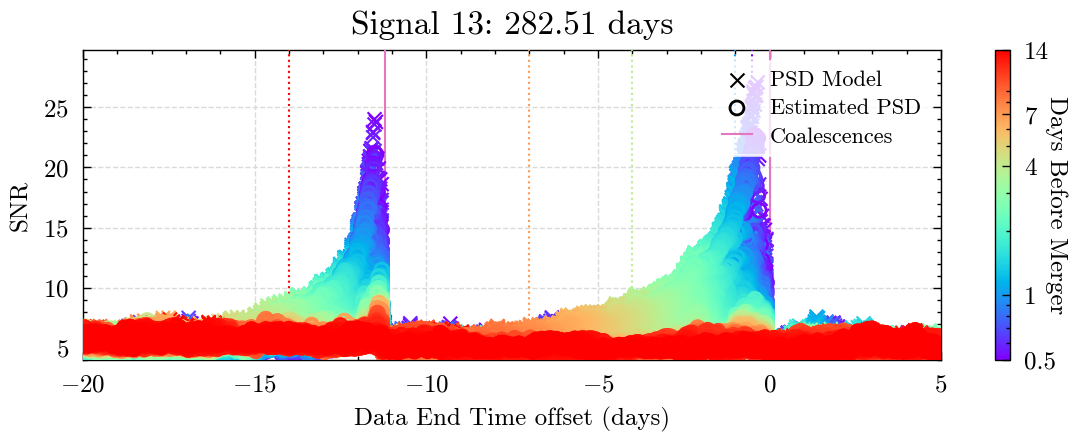

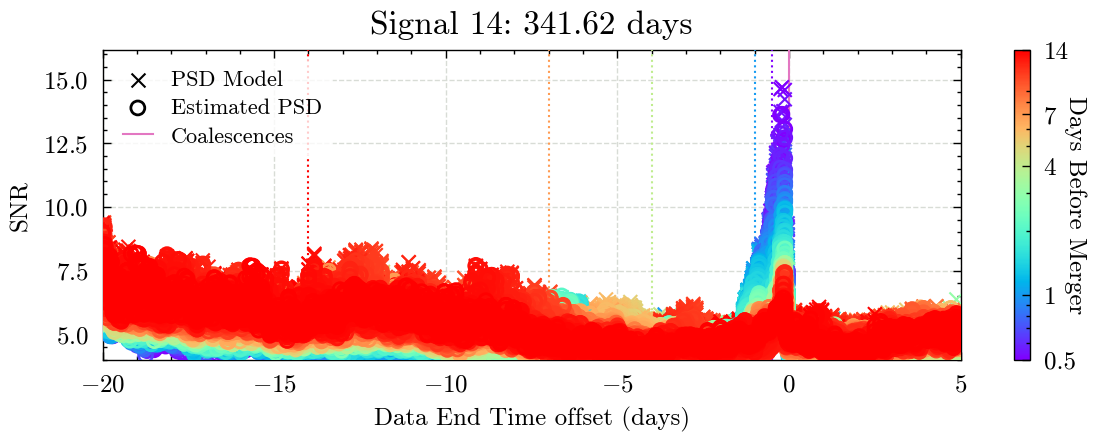

In [10]:
for i, truth_time_s in enumerate(truth_times_s):
    fig_model, _ = plotting_utils.plot_around_time(
        results_one=results_model_all,
        results_two=results_estimate_all,
        signal_truth_time=truth_time_s,
        truth_times=truth_times_s,
        start_time_offset=-20,
        end_time_offset=5,
        times_before=times_before,
        signal_number=i,
        label_one='PSD Model',
        label_two='Estimated PSD',
        legend_loc='upper right' if i in [5,12,13] else 'upper left',
        width_factor=2,
        predicted_time=False,
    )